In [1]:
import jax
import jax.numpy as jnp
import matplotlib.colors
import matplotlib.patches
import numpy as np
from matplotlib import pyplot as plt

from xxm.hmm import PoissonARHMM, match_states_by_conditional_mean

In [2]:
NUM_NEURONS = 10
NUM_TIME_STEPS = 5000
STATES_CMAP = matplotlib.colors.ListedColormap(['tab:blue', 'tab:orange', 'tab:green'])


def make_true_model_bimodal(
    num_neurons,
) -> tuple[PoissonARHMM, jax.Array, jax.Array]:
    baseline = jnp.full(num_neurons, 8.0)

    # Deterministic 2D population subspace.
    angles = jnp.linspace(
        0,
        2 * jnp.pi,
        num_neurons,
        endpoint=False,
    )

    basis = jnp.stack(
        [
            jnp.cos(angles),
            jnp.sin(angles),
        ],
        axis=1,
    )

    basis, _ = jnp.linalg.qr(basis)  # (N, 2)

    local_dynamics_2d = jnp.array(
        [
            # clockwise
            [
                [0.60, 0.25],
                [-0.25, 0.60],
            ],
            # counter-clockwise
            [
                [0.60, -0.25],
                [0.25, 0.60],
            ],
        ]
    )

    projection = basis @ basis.T
    orthogonal_projection = jnp.eye(num_neurons) - projection

    local_dynamics = jax.vmap(
        lambda dynamics: basis @ dynamics @ basis.T + 0.2 * orthogonal_projection
    )(local_dynamics_2d)  # (K, N, N)

    coefficients = (local_dynamics / baseline[:, None])[
        :, :, None, :
    ]  # (K, O=N, L=1, I=N)

    biases = jnp.log(baseline)[None, :] - jnp.einsum(
        'koi,i->ko',
        coefficients[:, :, 0, :],
        baseline,
    )

    model = PoissonARHMM.from_params(
        initial_probs=jnp.array([0.4, 0.6]),
        transition_probs=jnp.array(
            [
                [0.98, 0.02],
                [0.02, 0.98],
            ]
        ),
        emission_coefficients=coefficients,
        emission_bias=biases,
    )

    return model, basis, baseline


def make_true_model_monomodal(
    num_neurons,
) -> tuple[PoissonARHMM, jax.Array, jax.Array]:
    baseline = jnp.full(num_neurons, 8.0)

    # Deterministic 2D population subspace.
    angles = jnp.linspace(
        0,
        2 * jnp.pi,
        num_neurons,
        endpoint=False,
    )

    basis = jnp.stack(
        [
            jnp.cos(angles),
            jnp.sin(angles),
        ],
        axis=1,
    )

    basis, _ = jnp.linalg.qr(basis)  # (N, 2)

    local_dynamics_2d = jnp.array(
        [
            # clockwise
            [
                [0.60, 0.25],
                [-0.25, 0.60],
            ],
        ]
    )

    projection = basis @ basis.T
    orthogonal_projection = jnp.eye(num_neurons) - projection

    local_dynamics = jax.vmap(
        lambda dynamics: basis @ dynamics @ basis.T + 0.2 * orthogonal_projection
    )(local_dynamics_2d)  # (K, N, N)

    coefficients = (local_dynamics / baseline[:, None])[
        :, :, None, :
    ]  # (K, O=N, L=1, I=N)

    biases = jnp.log(baseline)[None, :] - jnp.einsum(
        'koi,i->ko',
        coefficients[:, :, 0, :],
        baseline,
    )

    model = PoissonARHMM.from_params(
        initial_probs=jnp.array([1.0]),
        transition_probs=jnp.array(
            [
                [1.0],
            ]
        ),
        emission_coefficients=coefficients,
        emission_bias=biases,
    )

    return model, basis, baseline


true_model, basis, baseline = make_true_model_bimodal(num_neurons=NUM_NEURONS)

true_states, observations = true_model.sample(
    num_steps=NUM_TIME_STEPS,
    key=jax.random.key(0),
)

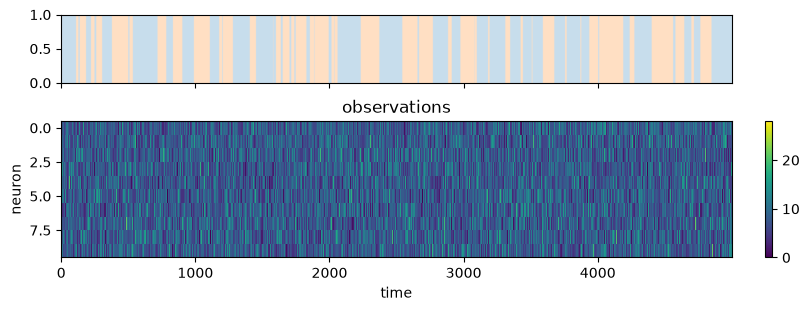

In [3]:
# def plot_latent(ax, latents, color='k', **kwargs):
#     ax.plot(latents[:, 0], latents[:, 1], color=color, **kwargs)
#     ax.scatter(latents[0, 0], latents[0, 1], color='g', zorder=10)
#     ax.scatter(latents[-1, 0], latents[-1, 1], color='r', zorder=10)
#     ax.set(title='latent states', aspect='equal')


def plot_state(ax, states, **kwargs):
    ax.imshow(
        states.reshape(-1, 1).T,
        aspect='auto',
        cmap=STATES_CMAP,
        vmin=0,
        vmax=2,
        alpha=0.25,
        extent=(0, len(states), 0, 1),
        transform=ax.get_xaxis_transform(),
    )


def plot_observations(ax, observations, **kwargs):
    im = ax.imshow(
        observations.T,
        aspect='auto',
        interpolation='none',
    )

    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xlabel='time',
        ylabel='neuron',
    )
    ax.set(title='observations')


def plot_data(true_states, observations):

    _f, axs = plt.subplots(
        nrows=2,
        sharex='all',
        figsize=(8, 3),
        constrained_layout=True,
        gridspec_kw={'height_ratios': [1, 2]},
    )

    ax = axs[0]

    plot_state(ax, true_states)

    ax = axs[1]
    plot_observations(ax, observations)


plot_data(true_states, observations)

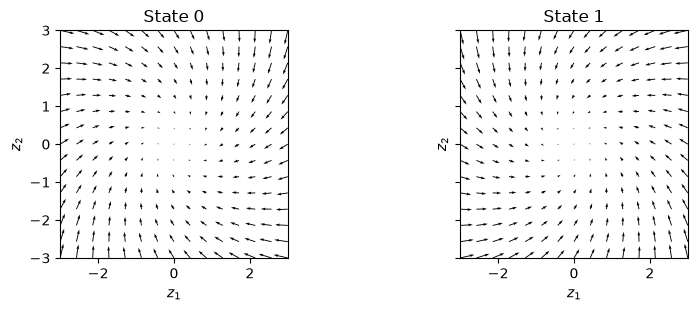

In [4]:
def plot_poisson_dynamics(
    ax,
    affine,
    basis,
    baseline,
    xlim=(-3, 3),
    ylim=(-3, 3),
    num_points=15,
    **kwargs,
):
    """Plot projected expected displacement of 2D Poisson AR(1) dynamics."""

    # Accept either ordinary vector input (N,) or AR(1) input (1, N).
    if affine.input_ndim == 2:
        if affine.input_shape[0] != 1:
            raise ValueError(
                'Poisson dynamics plotting only supports AR(1) dynamics; '
                f'got affine input shape {affine.input_shape}.'
            )

        affine = affine.input_squeeze()

    elif affine.input_ndim != 1:
        raise ValueError(
            'Affine input must be vector-shaped or AR(1)-structured; '
            f'got input shape {affine.input_shape}.'
        )

    coefficients = np.asarray(affine.coefficients)
    bias = np.asarray(affine.bias)
    basis = np.asarray(basis)
    baseline = np.asarray(baseline)

    num_neurons = baseline.shape[0]

    if affine.input_shape != (num_neurons,):
        raise ValueError(
            f'Affine input shape must match baseline shape {baseline.shape}; '
            f'got {affine.input_shape}.'
        )

    if affine.output_dim != num_neurons:
        raise ValueError(
            f'Affine output dimension must match baseline size {num_neurons}; '
            f'got {affine.output_dim}.'
        )

    if basis.shape != (num_neurons, 2):
        raise ValueError(
            f'Basis must have shape ({num_neurons}, 2); got {basis.shape}.'
        )

    x = np.linspace(*xlim, num_points)  # type: ignore
    y = np.linspace(*ylim, num_points)  # type: ignore
    xx, yy = np.meshgrid(x, y)

    # Coordinates in the 2D population subspace.
    z = np.stack([xx, yy], axis=-1)  # (..., 2)

    # Map into N-dimensional population activity around the fixed point.
    observations = baseline + z @ basis.T  # (..., N)

    # Expected next observation under the Poisson AR model.
    next_observations = np.exp(observations @ coefficients.T + bias)  # (..., N)

    # Project expected displacement back into the 2D subspace.
    displacement = (next_observations - observations) @ basis  # (..., 2)

    ax.quiver(
        xx,
        yy,
        displacement[..., 0],
        displacement[..., 1],
        **kwargs,
    )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal')
    ax.set_xlabel(r'$z_1$')
    ax.set_ylabel(r'$z_2$')


def plot_model_dynamics(model: PoissonARHMM) -> None:
    """Plot the expected displacement field of a 2D linear dynamics model."""

    _fig, axs = plt.subplots(
        ncols=model.num_states,
        figsize=(8, 3),
        sharex=True,
        sharey=True,
        constrained_layout=True,
        squeeze=False,
    )

    axs = axs.ravel()

    for state, ax in enumerate(axs):
        plot_poisson_dynamics(
            ax,
            affine=model.states.select(state).affine,
            basis=basis,
            baseline=baseline,
        )

        ax.set_title(f'State {state}')


plot_model_dynamics(true_model)

In [5]:
posterior, _ = true_model.infer(observations)

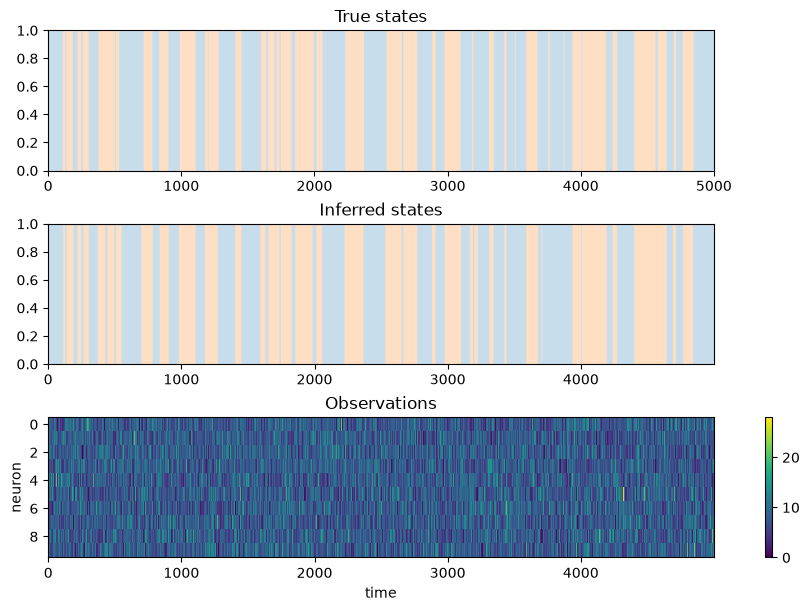

In [6]:
def plot_sequence_1d(
    ax,
    observations: jnp.ndarray,
    states: jnp.ndarray,
) -> None:
    observations = jnp.asarray(observations)
    states = jnp.asarray(states)

    ax.plot(observations.T[0], color='k')
    ax.plot(observations.T[1], color='xkcd:magenta')

    ax.set(xlabel='Time step', ylabel='Observations')


def plot_inferred_states(observations, true_states, posterior):
    _f, axs = plt.subplots(nrows=3, constrained_layout=True, figsize=(8, 6))

    ax = axs[0]
    plot_state(ax, true_states)
    ax.set(title='True states')

    ax = axs[1]

    inferred_states = posterior.state_probs.argmax(axis=1)
    plot_state(ax, inferred_states)
    ax.set(title='Inferred states')

    ax = axs[2]
    plot_observations(ax, observations)
    ax.set(title='Observations')


plot_inferred_states(observations, true_states, posterior)

EM:   0%|          | 0/100 [00:00<?, ?it/s]

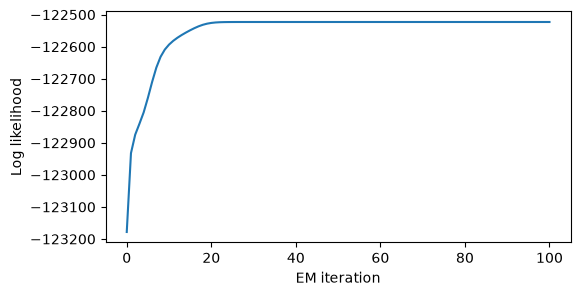

In [7]:
def plot_log_likelihood(log_likelihoods: jnp.ndarray) -> None:
    _f, ax = plt.subplots(figsize=(6, 3))

    ax.plot(np.asarray(log_likelihoods))

    ax.set_xlabel('EM iteration')
    ax.set_ylabel('Log likelihood')


initial_model = PoissonARHMM.from_kmeans(
    observations=observations,
    num_states=true_model.num_states,
    key=jax.random.key(0),
    num_lags=1,
)


learned_model, log_likelihoods = initial_model.fit(
    observations=observations,
    num_iters=100,
)


plot_log_likelihood(log_likelihoods)

In [8]:
permutation = match_states_by_conditional_mean(
    true_model.states_conditional(observations).log_rates,
    learned_model.states_conditional(observations).log_rates,
)

matched_model = learned_model.permute(permutation)

permutation

Array([1, 0], dtype=int32)

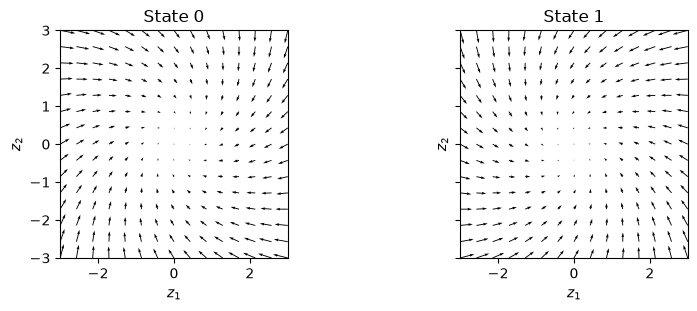

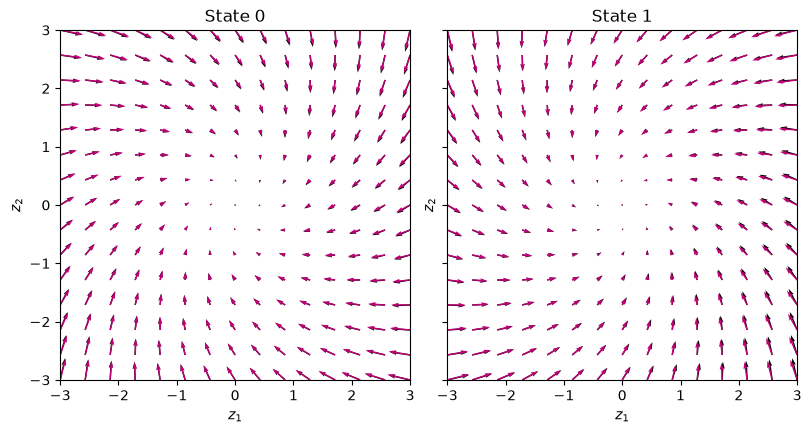

In [9]:
def plot_model_dynamics_comparison(model0: PoissonARHMM, model1: PoissonARHMM) -> None:
    """Plot the expected displacement field of a 2D linear dynamics model."""

    assert model0.num_states == model1.num_states, (
        'Models must have the same number of states.'
    )

    _fig, axs = plt.subplots(
        figsize=(8, 6),
        ncols=model0.num_states,
        sharex='all',
        sharey='all',
        constrained_layout=True,
        squeeze=False,
    )

    axs = axs.ravel()

    for state, ax in enumerate(axs):
        plot_poisson_dynamics(
            ax,
            affine=model0.states.select(state).affine,
            basis=basis,
            baseline=baseline,
            color='k',
        )

        plot_poisson_dynamics(
            ax,
            affine=model1.states.select(state).affine,
            basis=basis,
            baseline=baseline,
            color='xkcd:magenta',
        )

        ax.set_title(f'State {state}')


plot_model_dynamics(matched_model)
plot_model_dynamics_comparison(true_model, matched_model)

In [10]:
posterior_learnt, _ = matched_model.infer(observations)

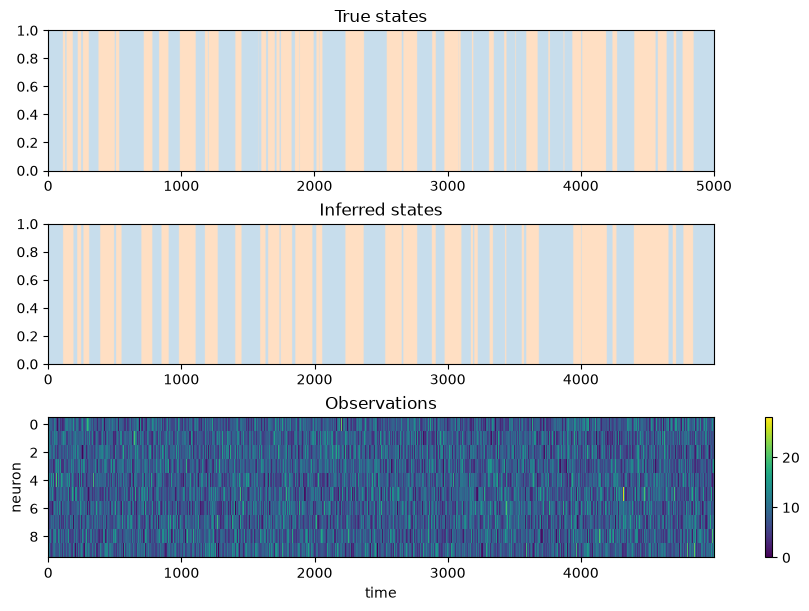

In [11]:
plot_inferred_states(observations, true_states, posterior_learnt)